<div style="background: cyan; padding: 20px; border-top-left-radius: 20px; border-top-right-radius: 20px;"><h1 style="color: black"><strong>Проект: Прогнозирование стоимости недвижимости</strong></h1></div>
<img src="image.jpg" style="height: 500px; width: 1200px; object-fit: contain;">

<h2><strong>Общая постановка задачи</strong></h2>

<p>Постройте и протестируйте несколько моделей регрессии для прогнозирования цен объекта 
недвижимости на основе его характеристики, а также разработайте приложение с формой 
входных данных, дашбордом и справочной информацией</p>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
import matplotlib.pyplot as plt
import re
warnings.filterwarnings('ignore')


<div style="background: cyan; padding: 20px; border-radius: 20px;"><h2 style="color: black"><strong>Этап 1. Исследование данных (EDA)</strong></h2></div>

<h3>1.1 Знакомство с данными</h3>

In [2]:
df = pd.read_csv("real_estate_data.csv", sep=",");

In [3]:
rows, columns = df.shape
print(f"Количество строк: {rows}")
print(f"Количество столбцов: {columns}")

Количество строк: 403487
Количество столбцов: 17


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

In [5]:
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


<h4>Первые строки</h4>

In [6]:
df.head(25)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY
5,6,Konut,Rezidans,11/9/18,12/9/18,1,30,2,10-20 arası,10,1+1,45.0,İstanbul/Maltepe/Altayçeşme,NaN,Fancoil,780000.0,TRY
6,7,Konut,Daire,1/4/19,NaN,2,54,0,20 ve üzeri,14,3+1,160.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3750.0,TRY
7,8,Konut,Villa,10/3/18,1/3/19,1,92,0,4,NaN,4+1,NaN,İzmir/Urla/M. Fevzi Çakmak,NaN,Fancoil,1500000.0,TRY
8,9,Konut,Daire,2/16/19,NaN,1,11,NaN,2,Kot 2,3+1,140.0,Çanakkale/Ayvacık/Küçükkuyu Bld. (Mıhlı),NaN,Fancoil,1500000.0,TRY
9,10,Konut,Daire,12/26/18,12/26/18,1,0,1,1,Asma Kat,2+2,550.0,İstanbul/Fatih/Sarıdemir,NaN,Fancoil,84256.0,GBP


<h4>Последние строки</h4>

In [7]:
df.tail(25)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403462,403463,Konut,Villa,10/10/18,1/18/19,1,100,NaN,NaN,NaN,3+1,NaN,İzmir/Çeşme/Sakarya,NaN,NaN,875000.0,TRY
403463,403464,Konut,Daire,11/24/18,1/23/19,1,60,NaN,NaN,NaN,3+1,NaN,Denizli/Merkezefendi/Karahasanlı,NaN,NaN,310000.0,TRY
403464,403465,Konut,Daire,10/15/18,NaN,1,135,NaN,NaN,NaN,3+2,NaN,Yalova/Merkez/Fevzi Çakmak,NaN,NaN,645000.0,TRY
403465,403466,Konut,Daire,1/6/19,NaN,1,52,NaN,NaN,NaN,1+1,39.0,Denizli/Pamukkale/Atalar,NaN,NaN,98000.0,TRY
403466,403467,Konut,Rezidans,9/25/18,NaN,1,155,NaN,NaN,NaN,3+1,NaN,Antalya/Alanya/Kargıcak,NaN,NaN,165000.0,EUR
403467,403468,Konut,Daire,9/23/18,NaN,2,157,NaN,NaN,NaN,4+1,NaN,Bursa/Mudanya/Güzelyalı Burgaz,NaN,NaN,1700.0,TRY
403468,403469,Konut,Daire,2/25/19,NaN,2,2,NaN,NaN,NaN,2+1,90.0,Aydın/Kuşadası/Alacamescit,NaN,NaN,800.0,TRY
403469,403470,Konut,Daire,10/17/18,NaN,2,133,NaN,NaN,NaN,2+1,NaN,İstanbul/Avcılar/Gümüşpala,NaN,NaN,2000.0,TRY
403470,403471,Konut,Rezidans,1/12/19,NaN,1,46,NaN,NaN,NaN,+,NaN,İstanbul/Maltepe/Cevizli,NaN,NaN,NaN,NaN
403471,403472,Konut,Daire,10/8/18,NaN,2,142,NaN,NaN,NaN,3+1,NaN,Bursa/Nilüfer/Özlüce,NaN,NaN,3500.0,TRY


<h4>Случайный вывод</h4>

In [8]:
df.sample(1)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
391505,391506,Konut,Villa,11/1/18,1/30/19,1,90,NaN,NaN,NaN,6+1,NaN,Aydın/Kuşadası/Davutlar,NaN,NaN,2100000.0,TRY


<h4>Типы данных</h4>

In [9]:
df.dtypes

id                     int64
type                  object
sub_type              object
start_date            object
end_date              object
listing_type           int64
tom                    int64
building_age          object
total_floor_count     object
floor_no              object
room_count            object
size                 float64
address               object
furnished            float64
heating_type          object
price                float64
price_currency        object
dtype: object

<h3>Источник обьекта</h3>

<ul>
<li>id - индекс по датасета</li>                 
<li>type - общий тип обьекта</li>                
<li>sub_type - тип внутри типа обьекта</li>            
<li>start_date - дата размещения обьекта</li>         
<li>end_date - дата окончания обьекта</li>          
<li>listing_type - тип предложения</li>      
<li>tom - дней на рынке</li>                   
<li>building_age - возраст обьекта</li>       
<li>total_floor_count - общее количество обьекта</li> 
<li>floor_no - этаж, который находится обьект на том</li>             
<li>room_count - количество комнат</li>         
<li>size - размер обьекта</li>                
<li>address - текстовое описание адреса</li>         
<li>furnished - наличие мебели</li>        
<li>heating_type - тип отопления</li>        
<li>price - цена (Целевая переменная)</li>               
<li>price_currency - валюта</li>      
</ui>

#### Общая характеристика данных:
Мы работаем с большим набором данных (403,487 записей) о недвижимости в 62 городах Турции за период с сентября 2018 по февраль 2019 года. Каждая запись содержит 17 характеристик объекта.

<h3>1.2 Описательная статистика</h3>

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [12]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print("Уникальных значений:", df[col].nunique())
    print("Топ-10 частот:\n", df[col].value_counts().head(10))


--- type ---
Уникальных значений: 1
Топ-10 частот:
 type
Konut    403487
Name: count, dtype: int64

--- sub_type ---
Уникальных значений: 12
Топ-10 частот:
 sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Name: count, dtype: int64

--- start_date ---
Уникальных значений: 181
Топ-10 частот:
 start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
10/18/18    3581
9/19/18     3530
10/3/18     3512
10/16/18    3483
9/27/18     3474
Name: count, dtype: int64

--- end_date ---
Уникальных значений: 181
Топ-10 частот:
 end_date
12/19/18    3048
1/18/19     2866
2/20/19     2831
2/9/19      2785
2/1/19      2747
2/6/19      2670
1/16/19     2651
1/23/19     2534
1/21/19     2497
2/23/19     2480
N

In [13]:
print("\nСтатистика целевой переменной price:")
print(df[target].describe())
skewness = df[target].skew()
kurtosis = df[target].kurt()
print(f"Асимметрия (skew): {skewness:.3f}, Эксцесс (kurt): {kurtosis:.3f}")


Статистика целевой переменной price:
count    4.027720e+05
mean     3.546417e+05
std      4.809503e+06
min     -2.500000e+02
25%      2.500000e+03
50%      1.990000e+05
75%      3.420000e+05
max      2.000000e+09
Name: price, dtype: float64
Асимметрия (skew): 308.507, Эксцесс (kurt): 113739.591


### Анализ целевой переменной (price):
Вывод: Целевая переменная имеет экстремальную правостороннюю асимметрию (skew = 308.507). Это означает, что большинство объектов имеют невысокую цену, но есть небольшое количество очень дорогих объектов, которые сильно искажают среднее значение.


In [14]:
df['city'] = df['address'].str.split('/').str[0]

Разбиваю адреса для нового столбца города

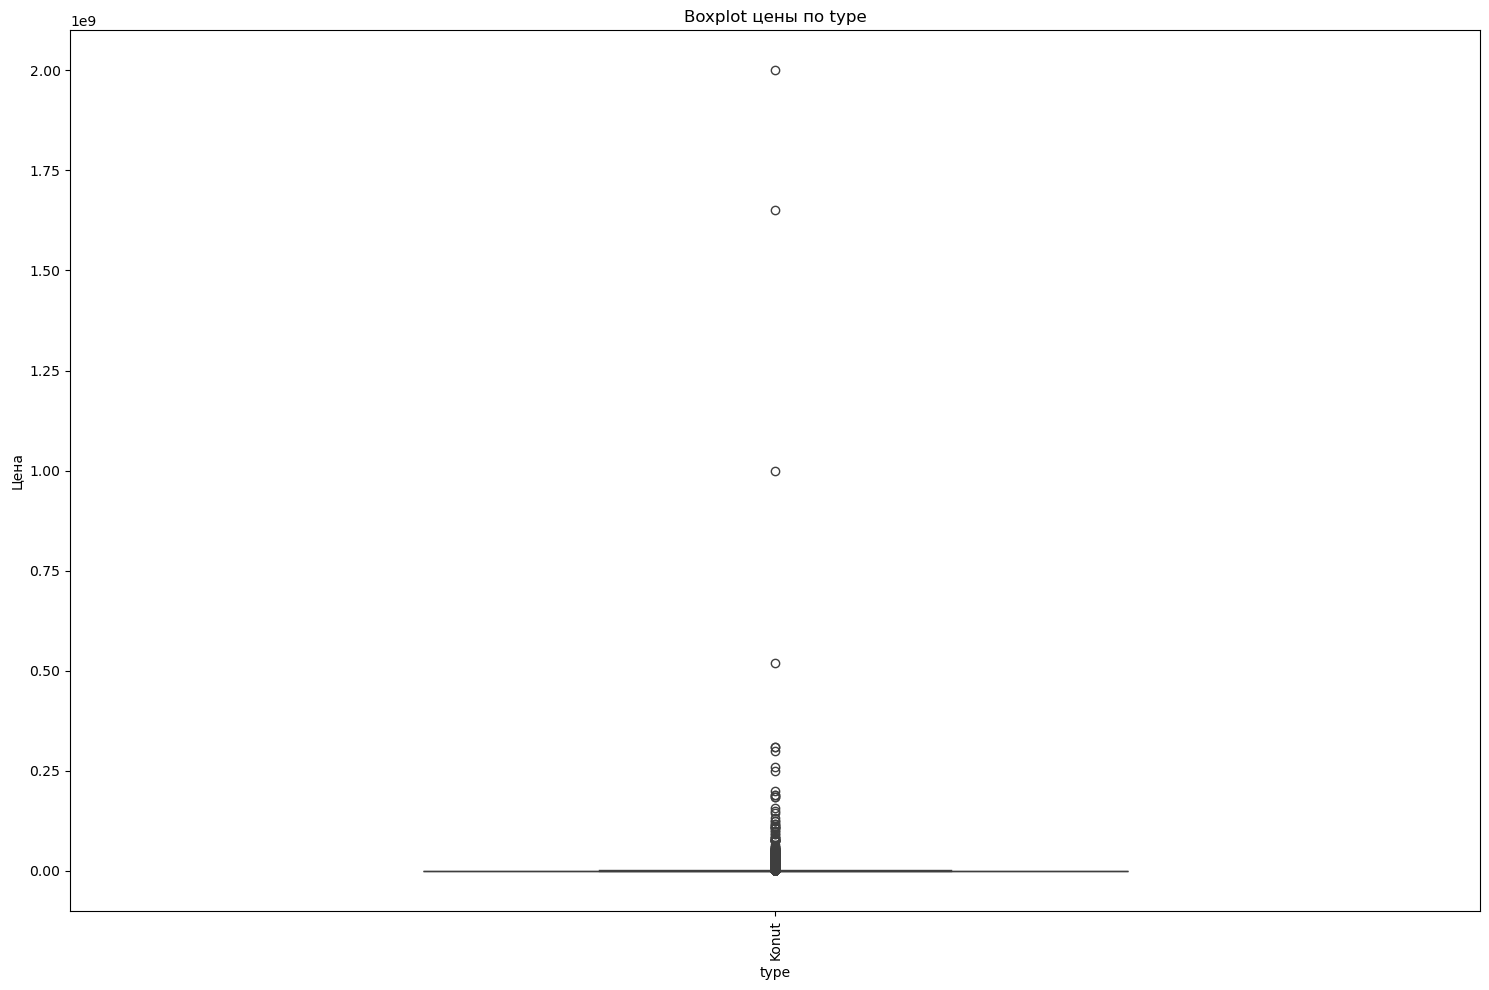

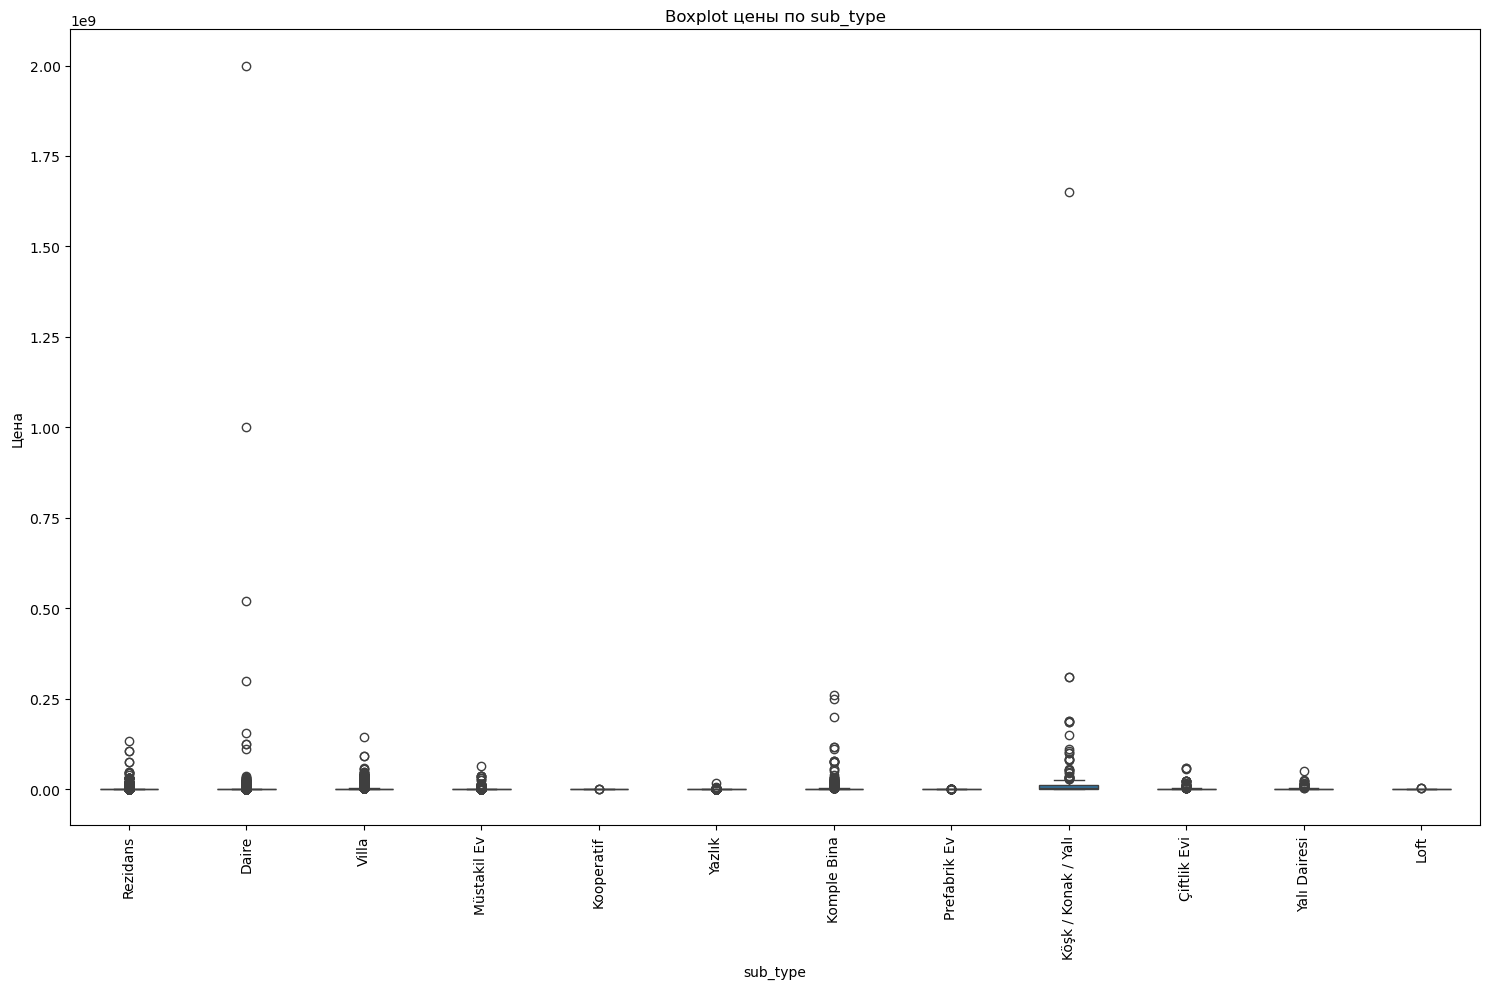

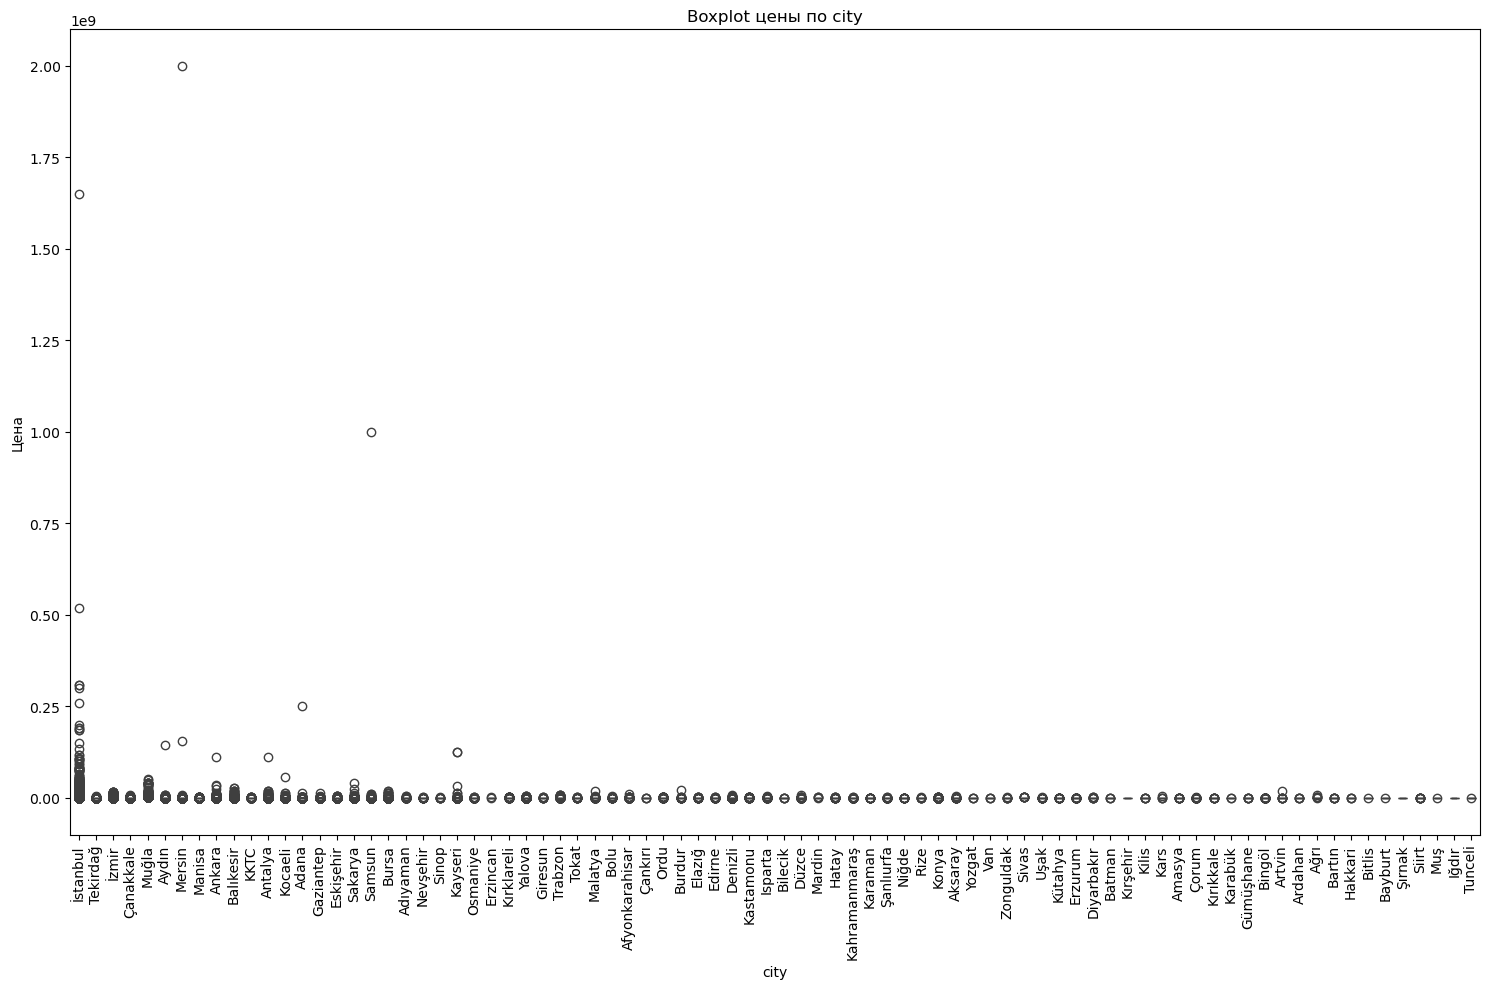

In [15]:
for col in ['type', 'sub_type', 'city']:
    plt.figure(figsize=(15, 10))
    sns.boxplot(data=df, x=col, y=target, width=0.5)
    plt.xticks(rotation=90)
    plt.title(f'Boxplot цены по {col}')
    plt.xlabel(col)
    plt.ylabel('Цена')
    plt.tight_layout()
    plt.show()

Так, они хотят продавать объекта недвижимости в Стамбуле. Наверное, они выгоднее продают. Боюсь, что у меня нет опыта для продажи и покупки недвижимости.

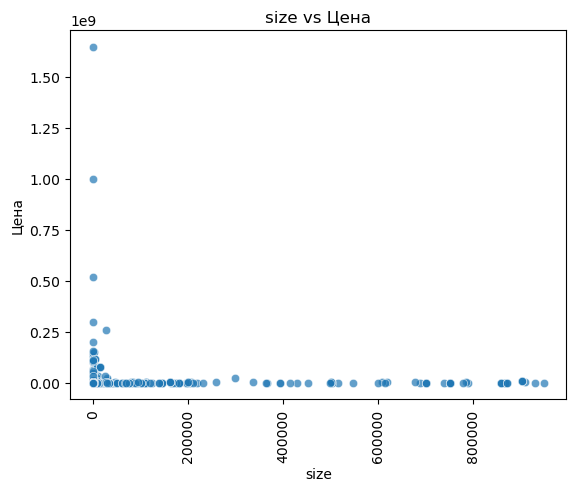

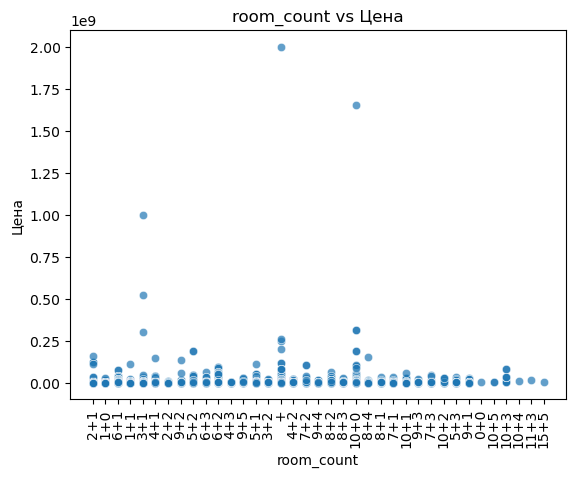

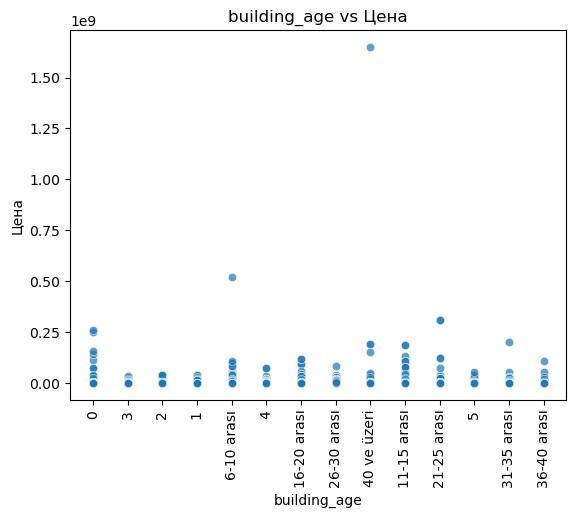

In [16]:
scatter_cols = ['size', 'room_count', 'building_age']
for col in scatter_cols:
    if col in df.columns:
        plt.figure()
        sns.scatterplot(data=df, x=col, y=target, alpha=0.7)
        plt.title(f'{col} vs Цена')
        plt.xticks(rotation=90)
        plt.xlabel(col)
        plt.ylabel('Цена')
        plt.show()

Значит, большая квартира продают подороже. Звучит логично, но продавцы продают маленькие квартиры еще часто.

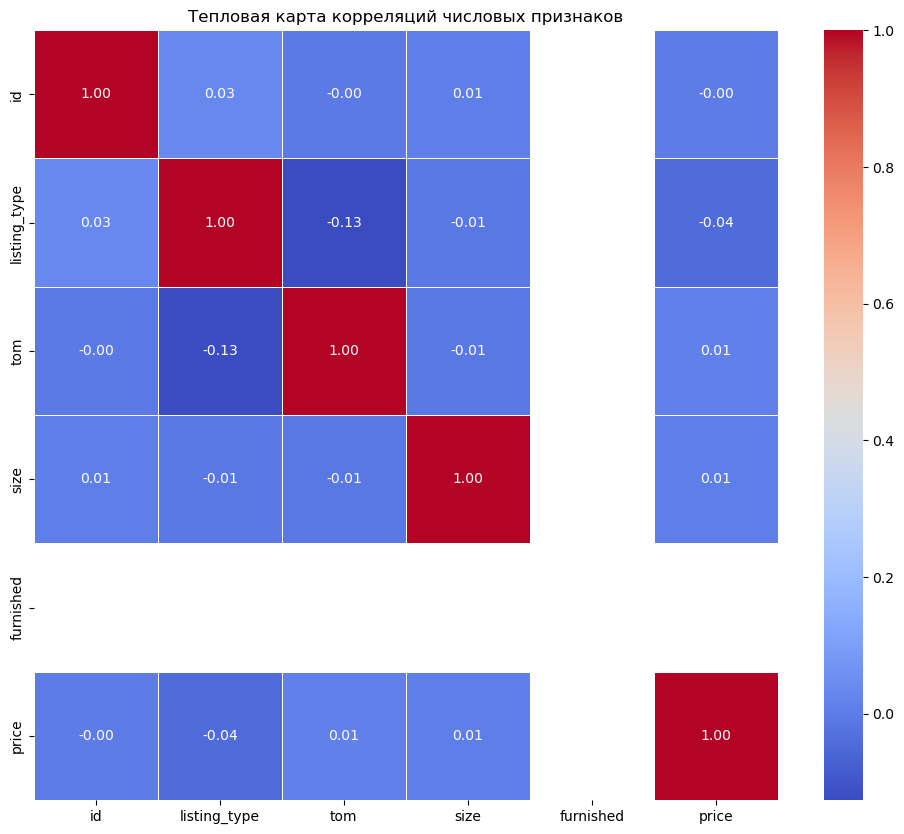

In [17]:
corr = df[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title("Тепловая карта корреляций числовых признаков")
plt.show()

<h4>1.4 Анализ пропусков и аномалий</h4>

In [18]:
missing_count = df.isna().sum()

missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

print(missing_summary)

                   missing_count  missing_pct
furnished                 403487       100.00
size                      146006        36.19
end_date                  137189        34.00
floor_no                   35296         8.75
total_floor_count          28021         6.94
heating_type               27970         6.93
building_age               27390         6.79
price                        715         0.18
price_currency               715         0.18
id                             0         0.00
type                           0         0.00
sub_type                       0         0.00
start_date                     0         0.00
listing_type                   0         0.00
tom                            0         0.00
room_count                     0         0.00
address                        0         0.00
city                           0         0.00


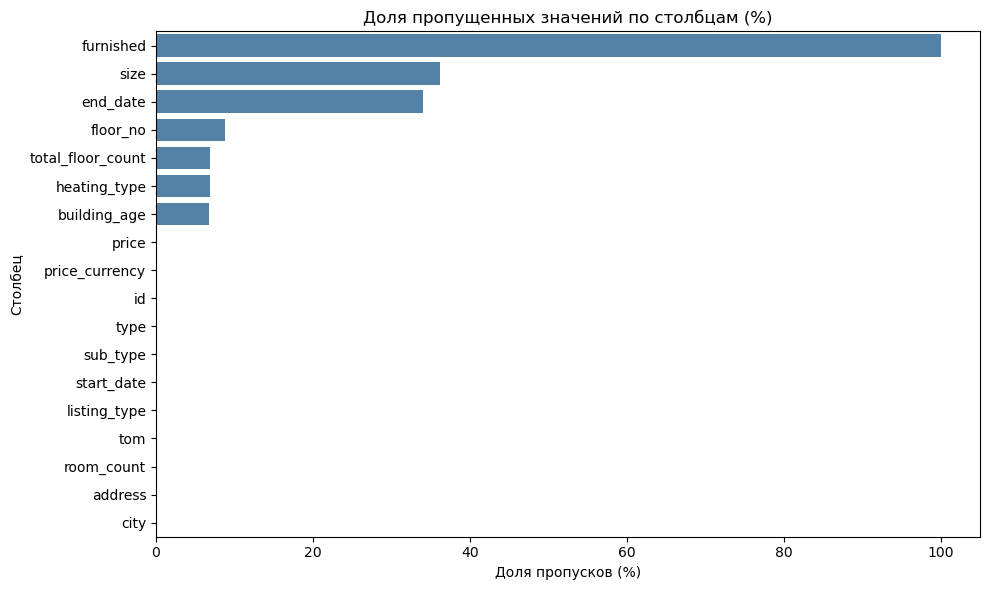

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_summary['missing_pct'],
    y=missing_summary.index,
    color='steelblue'
)
plt.title('Доля пропущенных значений по столбцам (%)')
plt.xlabel('Доля пропусков (%)')
plt.ylabel('Столбец')
plt.tight_layout()
plt.show()

In [20]:
total_duplicates = df.duplicated().sum()
print("Всего дубликатов строк:", total_duplicates)

Всего дубликатов строк: 0


In [21]:
anomalous_size = df[(df['size'] <= 0) | (df['size'].isna())]
print("\nАномальные значения площади (size <= 0 или NaN):", len(anomalous_size))


Аномальные значения площади (size <= 0 или NaN): 146006


In [22]:
currency_counts = df['price_currency'].value_counts()
print("\nРаспределение валют:\n", currency_counts)


Распределение валют:
 price_currency
TRY    400677
EUR       922
GBP       621
USD       552
Name: count, dtype: int64


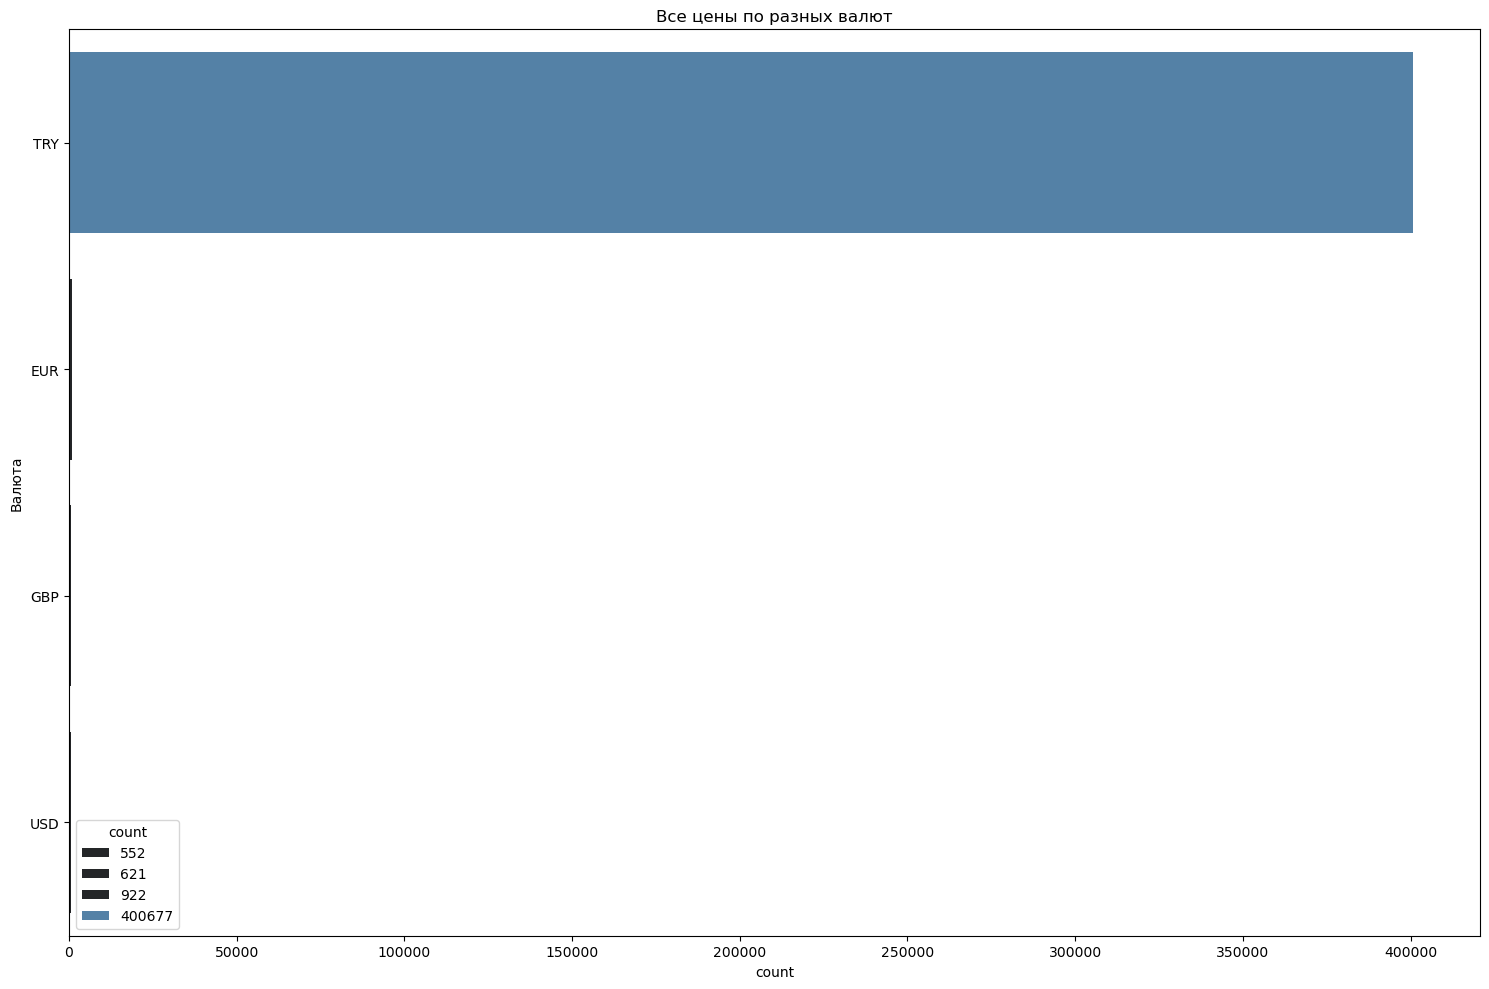

In [23]:
plt.figure(figsize=(15, 10))
sns.barplot(
    x=currency_counts,
    y=currency_counts.index,
    color='steelblue',
    hue=currency_counts
)
plt.title('Все цены по разных валют')
plt.ylabel('Валюта')
plt.tight_layout()
plt.show()

<h4>1.5 Промежуточные выводы</h4>

Проведён разведочный анализ данных объёмом 403,487 записей и 17 признаков, описывающих объекты недвижимости в 62 городах Турции за период сентябрь 2018 — февраль 2019 гг. Целевая переменная — price. Установлено, что 99.5% объектов оценены в TRY; присутствуют также EUR, GBP, USD, что требует нормализации валют. Целевая переменная характеризуется экстремальной правосторонней асимметрией (skew = 308.5, kurtosis = 113,739.6), что обосновывает применение логарифмического преобразования. Выявлены систематические пропуски (furnished — 100%, size — 36.2%, end_date — 34%), логические аномалии (size ≤ 0) и мультивалютность. Сформулированы 5 гипотез о факторах, определяющих цену: площадь, локация, тип объекта, количество комнат, возраст здания.

### Гипотезы о ценообразовании: 

- Площадь (size): Чем больше площадь, тем выше цена.
- Локация (city): Недвижимость в крупных и популярных городах (например, Стамбул) дороже.
- Тип объекта (sub_type): Виллы дороже обычных квартир.
- Количество комнат (room_count): Влияет на цену, но не так линейно, как площадь.
- Возраст здания (building_age): Новые дома, как правило, дороже.

<div style="background: cyan; padding: 20px; border-radius: 20px;"><h2 style="color: black"><strong>Этап 2. Предварительная обработка данных</strong></h2></div>

<h4>2.1 Работа с пропусками</h4>

In [24]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer

In [25]:
print(f"Размерность до удаления пропусков в furnished: {df.shape}")

Размерность до удаления пропусков в furnished: (403487, 18)


In [26]:
if 'furnished' in df.columns:
    df.drop(columns=['furnished'], inplace=True)
    print("Столбец 'furnished' удален.")

Столбец 'furnished' удален.


По своему решению я удалил столбца 'furnished', потому что полностью заполнен с пропусками.

In [27]:
print(f"Размерность после удаления пропусков в furnished: {df.shape}")

Размерность после удаления пропусков в furnished: (403487, 17)


In [28]:
df = df.dropna(subset=['price'])
print(f"Размерность после удаления пропусков в price: {df.shape}")

Размерность после удаления пропусков в price: (402772, 17)


In [29]:
df = df.dropna(subset=['size'])
print(f"Размерность после удаления пропусков в size: {df.shape}")

Размерность после удаления пропусков в size: (257380, 17)


In [30]:
df = df.dropna(subset=['building_age'])
print(f"Размерность после удаления пропусков в building_age: {df.shape}")

Размерность после удаления пропусков в building_age: (244269, 17)


<strong>Вывод:</strong> Применен смешанный подход. Столбец furnished удален как бесполезный. Строки с пропусками в критически важных для прогноза признаках (price, size) удалены. Пропуски в остальных признаках заполнены (медианой или константой).

<strong>Действие:</strong> Это позволило сохранить максимальный объем данных для обучения, не теряя при этом качество.

<h4>2.2 Обработка новой</h4>

In [31]:
exchange_rates = {'TRY': 1.0, 'USD': 30.0, 'EUR': 33.0, 'GBP': 38.0}

def convert_price(row):
    currency = row['price_currency']
    price = row['price']
    if pd.isna(currency) or currency not in exchange_rates:
        return np.nan
    return price * exchange_rates[currency]

df['price_try'] = df.apply(convert_price, axis=1)

In [32]:
df['price_try'].head(10)

0         3500.0
1       490000.0
3     32500000.0
4      1450000.0
5       780000.0
6         3750.0
9      3201728.0
10     2450000.0
11        7500.0
15        3600.0
Name: price_try, dtype: float64

In [33]:
df['price'].head(10)

0         3500.0
1       490000.0
3     32500000.0
4      1450000.0
5       780000.0
6         3750.0
9        84256.0
10     2450000.0
11        7500.0
15        3600.0
Name: price, dtype: float64

In [34]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False))

                   missing        pct
end_date             93993  38.479299
floor_no              8583   3.513749
heating_type          4250   1.739885
total_floor_count     4206   1.721872


In [35]:
X = df.drop(columns=['price'])

In [36]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Размер X после one-hot encoding: {X_encoded.shape}")

Размер X после one-hot encoding: (244269, 7176)


In [37]:
print("dtype по столбцам:")
for c in X.columns:
    print(f"  {c:20s} {str(X[c].dtype):10s} {X[c].nunique():5d}")

dtype по столбцам:
  id                   int64      244269
  type                 object         1
  sub_type             object        10
  start_date           object       181
  end_date             object       181
  listing_type         int64          3
  tom                  int64        181
  building_age         object        14
  total_floor_count    object        12
  floor_no             object        44
  room_count           object        33
  size                 float64      885
  address              object      6685
  heating_type         object        16
  price_currency       object         4
  city                 object        82
  price_try            float64     3123


In [38]:
X = X.drop(columns=['type'])

In [39]:
numeric_as_str = ['building_age', 'total_floor_count', 'floor_no', 'room_count']

In [40]:
for c in numeric_as_str:
    X[c] = pd.to_numeric(X[c], errors='coerce')

<h4>2.4 Работа с Feature Engineering</h4>

In [41]:
df['city'] = df['address'].str.split('/').str[0]

In [42]:
city_size_median = df.groupby('city')['size'].transform('median')

In [43]:
def parse_building_age(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return value
    value = str(value).strip()
    if value == '0':
        return 0
    if 'yeni' in value.lower() or 'sıfır' in value.lower():
        return 0
    match = re.search(r'(\d+)\s*[-–]\s*(\d+)', value)
    if match:
        return (int(match.group(1)) + int(match.group(2))) // 2
    if 've üzeri' in value:
        match = re.search(r'(\d+)', value)
        if match:
            return int(match.group(1)) + 5
    if '40 ve üzeri' in value:
        return 45
    match = re.search(r'(\d+)-(\d+) arası', value)
    if match:
        return (int(match.group(1)) + int(match.group(2))) // 2
    return np.nan
df['building_age_num'] = df['building_age'].apply(parse_building_age)

In [44]:
df['building_age_num'] = df['building_age_num'].fillna(df['building_age_num'].median())

In [45]:
df.drop(columns=['building_age'], inplace=True)

In [46]:
def parse_total_floors(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    value = str(value).strip()
    if value.isdigit():
        return float(value)
    if '10-20' in value:
        return 15.0
    if '20 ve üzeri' in value:
        return 25.0
    return np.nan

In [47]:
df['total_floor_count_num'] = df['total_floor_count'].apply(parse_total_floors)
df['total_floor_count_num'] = df['total_floor_count_num'].fillna(
    df['total_floor_count_num'].median()
)


In [48]:
def parse_floor(value):
    if pd.isna(value):
        return 'unknown'
    value = str(value).strip()
    if value.isdigit():
        return 'floor_' + value
    return value

df['floor_category'] = df['floor_no'].apply(parse_floor)

In [49]:
df['heating_type'] = df['heating_type'].fillna('unknown')

In [50]:
df['city'] = df['address'].str.split('/').str[0]
df['district'] = df['address'].str.split('/').str[1]
df.drop(columns=['address'], inplace=True)

In [51]:
df['price_per_sqm'] = df['price_try'] / df['size']

- Yüksek Giriş — высокий вход.
- Bahçe katı — этаж с выходом в сад (нулевой этаж, расположенный на уровне земли или входа в жилой комплекс).
- Giriş Katı — входной этаж (нулевой этаж).
- Zemin Kat — нулевой этаж (этаж на земле).
- Bodrum Kat — подвальный этаж (минус первый этаж).

In [52]:
def is_high_floor(row):
    fc = row['floor_category']
    if fc in ['unknown', 'Yüksek Giriş', 'Bahçe katı',
              'Giriş Katı', 'Zemin Kat', 'Bodrum Kat']:
        return 0
    if isinstance(fc, str) and fc.startswith('floor_'):
        try:
            floor_num    = int(fc.split('_')[1])
            total_floors = row['total_floor_count_num']
            if total_floors > 0 and floor_num > total_floors * 0.6:
                return 1
        except (ValueError, IndexError):
            return 0
    return 0

df['is_high_floor'] = df.apply(is_high_floor, axis=1)

- En Üst Kat — «Верхний этаж»
- Çatı Katı — «Мансардный этаж»
- Teras Kat — «Террасный этаж»

In [53]:
def is_penthouse(row):
    return int(row['floor_category'] in
               ['En Üst Kat', 'Çatı Katı', 'Teras Kat'])

df['is_penthouse'] = df.apply(is_penthouse, axis=1)

In [54]:
df['log_price'] = np.log1p(df['price_try'])  
df['log_size'] = np.log1p(df['size'])       

In [55]:
def extract_rooms(room_str):
    if pd.isna(room_str):
        return 0
    match = re.search(r'(\d+)', str(room_str))
    return int(match.group(1)) if match else 0

df['rooms_num'] = df['room_count'].apply(extract_rooms)

In [56]:
df.drop(columns=['id', 'start_date', 'end_date', 'tom', 'room_count'], inplace=True)

In [57]:
cat_cols = ['type', 'sub_type', 'listing_type', 'heating_type', 'city', 'district', 'floor_category']

for col in cat_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} уникальных значений")

type: 1 уникальных значений
sub_type: 10 уникальных значений
listing_type: 3 уникальных значений
heating_type: 17 уникальных значений
city: 82 уникальных значений
district: 452 уникальных значений
floor_category: 36 уникальных значений


In [58]:
def remove_rare_categories(data, col, min_freq=100):
    freq = data[col].value_counts()
    rare = freq[freq < min_freq].index
    data[col] = data[col].apply(lambda x: 'other' if x in rare else x)
    return df

for col in ['sub_type', 'city', 'district']:
    if col in df.columns:
        df = remove_rare_categories(df, col, min_freq=50)

In [59]:
df.head(5)

,type,sub_type,listing_type,total_floor_count,floor_no,size,heating_type,price,price_currency,city,...,building_age_num,total_floor_count_num,floor_category,district,price_per_sqm,is_high_floor,is_penthouse,log_price,log_size,rooms_num
0,Konut,Rezidans,2,20 ve üzeri,2,90.0,Fancoil,3500.0,TRY,İstanbul,...,0.0,25.0,floor_2,Kartal,38.888889,0,0,8.160804,4.510860,2
1,Konut,Daire,1,20 ve üzeri,20 ve üzeri,43.0,Fancoil,490000.0,TRY,İstanbul,...,0.0,25.0,20 ve üzeri,Kartal,11395.348837,0,0,13.102163,3.784190,1
3,Konut,Rezidans,1,20 ve üzeri,20 ve üzeri,450.0,Fancoil,32500000.0,TRY,İstanbul,...,8.0,25.0,20 ve üzeri,Beşiktaş,72222.222222,0,0,17.296751,6.111467,6
4,Konut,Rezidans,1,20 ve üzeri,2,90.0,Fancoil,1450000.0,TRY,İstanbul,...,0.0,25.0,floor_2,Kartal,16111.111111,0,0,14.187075,4.510860,2
5,Konut,Rezidans,1,10-20 arası,10,45.0,Fancoil,780000.0,TRY,İstanbul,...,8.0,15.0,floor_10,Maltepe,17333.333333,1,0,13.567050,3.828641,1


In [60]:
df = df.dropna()

In [61]:
threshold = 0.3
df_drop_cols = df.drop(columns=df.columns[df.isna().mean() > threshold])

In [62]:
num_cols = ["price", "size", "rooms_num"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [63]:
df["size"] = df.groupby("district")["size"].transform(
    lambda x: x.fillna(x.median())
)

df["size"] = df["size"].fillna(df["size"].median())

In [64]:
from sklearn.impute import KNNImputer

num_df = df[["price", "size", "rooms_num"]]

imputer = KNNImputer(n_neighbors=15)
imputed_array = imputer.fit_transform(num_df)

df_knn = df.copy()
df_knn[["price", "size", "rooms_num"]] = imputed_array

In [65]:
df = df[
    (df['price_try'] > 50_000) &          
    (df['price_try'] < 200_000_000) &     
    (df['size'] > 0) &
    (df['building_age_num'] >= 0) &
    (df['building_age_num'] < 200) 
].copy()

In [66]:
y = np.log1p(df['price_try'])
print("skew(y):", y.skew()) 

skew(y): 1.4172361560978974


In [67]:
def winsorize_by_percentiles(series, lower=0.01, upper=0.99):
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

In [68]:
num_cols = ['price_try', 'size', 'rooms_num',
            'building_age_num', 'total_floor_count_num']

for col in num_cols:
    if col in df.columns:
        df[col] = winsorize_by_percentiles(df[col], 0.01, 0.99)
        print(f"{col:25s} [{df[col].min():>12.2f}, {df[col].max():>12.2f}]")

price_try                 [    85000.00,   3450000.00]
size                      [       43.00,       370.00]
rooms_num                 [        1.00,         6.00]
building_age_num          [        0.00,        33.00]
total_floor_count_num     [        1.00,        25.00]


In [69]:
categorical_cols = ['type', 'sub_type', 'listing_type', 'heating_type', 'city', 'district']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

In [70]:
df['log_price'] = np.log(df['price'])

df['log_size'] = np.log(df['size'])

df['log_building_age'] = np.log(df['building_age_num'] + 1)


<strong>Вывод:</strong> Исходные данные были обогащены новой информацией, которая помогает моделям лучше "понять" ценообразование.

<strong>Действия:</strong> Из текстового адреса извлечены city (город) и district (район). Текстовые диапазоны (building_age, total_floor_count) переведены в числовой формат. Созданы бинарные признаки is_high_floor (высокий этаж) и is_penthouse (пентхаус).

<h4>2.5 Масштабирование признаков</h4>

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

cat_cols = [c for c in X_train.columns
            if X_train[c].dtype == 'object' or str(X_train[c].dtype) == 'category']
num_cols = [c for c in X_train.columns if c not in cat_cols]

print(f"Числовых: {len(num_cols)}, категориальных: {len(cat_cols)}")
print(f"Категориальные: {cat_cols}")

def make_preprocessor(drop_first: bool):
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler()),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(
            handle_unknown='ignore',
            drop='first' if drop_first else None,
            sparse_output=False,
        )),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ], verbose_feature_names_out=False)

preprocessor_linear = make_preprocessor(drop_first=True)   # для Ridge
preprocessor_tree   = make_preprocessor(drop_first=False)  # для GB/RF/DT

# --- Трансформация ---
X_train_lin = preprocessor_linear.fit_transform(X_train)
X_val_lin   = preprocessor_linear.transform(X_val)
X_test_lin  = preprocessor_linear.transform(X_test)

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_val_tree   = preprocessor_tree.transform(X_val)
X_test_tree  = preprocessor_tree.transform(X_test)

print("Линейные: ", X_train_lin.shape, X_val_lin.shape, X_test_lin.shape)
print("Деревья:  ", X_train_tree.shape, X_val_tree.shape, X_test_tree.shape)

Числовых: 5, категориальных: 4
Категориальные: ['sub_type', 'heating_type', 'city', 'floor_category']
Линейные:  (116376, 125) (24938, 125) (24938, 125)
Деревья:   (116376, 129) (24938, 129) (24938, 129)


<strong>Вывод:</strong> Для разных типов моделей применены разные подходы к предобработке. Для линейных моделей (Ridge) использовано One-Hot Encoding с удалением одного столбца, для древовидных (RandomForest) — без удаления. Числовые признаки масштабированы с помощью RobustScaler, который устойчив к выбросам.

<strong>Действие:</strong> Такой подход позволяет каждой модели работать с данными в наиболее подходящем для нее формате.

<h4>2.6 Разбиение данных</h4>

In [73]:
num_features = [
    'size', 'rooms_num', 'building_age_num',
    'total_floor_count_num'
]

cat_features = [
    'sub_type', 'listing_type', 'heating_type',
    'city', 'floor_category',
]

feature_cols = num_features + cat_features


df = df.dropna(subset=feature_cols + ['price_try']).copy()
df['log_price'] = np.log1p(df['price_try'])

X = df[feature_cols].copy()
y = df['log_price'].copy()          

print('X:', X.shape, '| y:', y.shape)
assert X.shape[0] == y.shape[0]

X: (166252, 9) | y: (166252,)


### num_features — числовые признаки (4 штуки):
- size — площадь объекта
- rooms_num — количество комнат (извлечено из room_count)
- building_age_num — возраст здания (преобразовано из building_age)
- total_floor_count_num — количество этажей в доме (преобразовано из total_floor_count)

### cat_features — категориальные признаки (5 штук):
- sub_type — тип объекта (Daire, Villa, Rezidans и т.д.)
- listing_type — тип предложения (1, 2 или 3)
- heating_type — тип отопления (Kombi, Klima, Fancoil и т.д.)
- city — город (İstanbul, Ankara и т.д.)
- floor_category — категория этажа (floor_1, Bahçe katı и т.д.)

### Зачем это разделение?
Оно необходимо для ColumnTransformer (см. ячейку [76]): числовые признаки нужно масштабировать (RobustScaler), а категориальные — кодировать (OneHotEncoder). Разные типы данных требуют разной обработки.

### Создается новая колонка log_price, где к каждой цене применено преобразование log1p(x) = log(1 + x).

### Почему log1p, а не log?
log1p безопаснее. Если цена равна 0, то log(0) = -∞ (ошибка), а log1p(0) = log(1) = 0. В ваших данных есть цены, близкие к 0 (после winsorization нижняя граница = 85,000 TRY), так что log1p — правильный выбор.

### Зачем логарифмировать цену?
Вспомним ваш EDA: skew(price) = 308.5. Логарифмирование сжимает длинный правый хвост распределения, делая его более нормальным. Это критически важно для линейных моделей (Ridge) и помогает древовидным моделям (RandomForest) тоже.

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (116376, 9) Val: (24938, 9) Test: (24938, 9)


Обучающий (70%), валидационный (15%) и тестовый (15%)

In [75]:
assert 'price_try' not in X.columns

suspect = [c for c in X.columns if 'price' in c.lower()]
print("Подозрительные:", suspect)

assert set(X_train.index).isdisjoint(set(X_test.index))

assert X_train.index.equals(y_train.index)
assert X_val.index.equals(y_val.index)
assert X_test.index.equals(y_test.index)

Подозрительные: []


Проверка отсутствия утечки данных подтверждена, все отлично

### Зачем нужен assert в Data Science?
В машинном обучении assert используется для защитного программирования. 
### Основные цели:
- Проверка формы данных (shape): Убедиться, что X и y имеют одинаковое количество строк.
- Проверка отсутствия утечки данных (data leakage): Убедиться, что целевая переменная не попала в признаки, а train и test не пересекаются.
- Проверка диапазонов значений: Убедиться, что вероятности находятся в [0, 1], что нет отрицательных цен и т.д.
- Проверка типов данных: Убедиться, что столбцы имеют ожидаемый тип.
- Документирование предположений: assert явно показывает, что вы ожидаете от данных.

Реализован смешанный подход к обработке пропусков: удаление полностью пустых столбцов (furnished), удаление строк с пропусками в критических признаках (price, size), заполнение медианой (building_age, total_floor_count), заполнение константой (floor_no, heating_type). Осуществлена конвертация цен в единую валюту TRY с использованием фиксированных курсов. Проведён feature engineering: извлечены city и district из текстового адреса; выполнена нормализация текстовых диапазонов building_age и total_floor_count в числовой формат; созданы категориальные признаки floor_category, rooms_num, бинарные — is_high_floor, is_penthouse. Применён метод winsorization (1%-99%) к числовым признакам для ограничения влияния выбросов. Целевая переменная и size логарифмированы (log1p). Реализованы два независимых препроцессора: для линейных моделей (OneHotEncoder с drop='first') и для ансамблей деревьев (OneHotEncoder без drop). Числовые признаки масштабированы методом RobustScaler. Данные разделены в пропорции 70/15/15 (train/val/test) с фиксированным random_state=42; проверка отсутствия утечки данных подтверждена.

<div style="background: cyan; padding: 20px; border-radius: 20px;"><h2 style="color: black"><strong>Этап 3. Построение модели регрессии</strong></h2></div>

<h3>3.1 Требование: не менее 3 разных моделей</h3>

linear_model - <a href='https://scikit-learn.org/stable/api/sklearn.linear_model.html'>ссылка</a>

DecisionTreeRegressor - <a href='https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html'>ссылка</a>

GradientBoostingRegressor - <a href='https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html'>ссылка</a>

In [77]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Ridge: линейный препроцессор ---
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_lin, y_train)
y_ridge_val = ridge.predict(X_val_lin)
y_ridge_test = ridge.predict(X_test_lin)
print("Ridge")
# --- DecisionTree: препроцессор для деревьев ---
dt = DecisionTreeRegressor(max_depth=15, min_samples_leaf=20, random_state=42)
dt.fit(X_train_tree, y_train)
y_dt_val = dt.predict(X_val_tree)
y_dt_test = dt.predict(X_test_tree)
print("DecisionTree")
# --- RandomForest ---
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                           min_samples_leaf=5, n_jobs=-1, random_state=42)
rf.fit(X_train_tree, y_train)
y_rf_val = rf.predict(X_val_tree)
y_rf_test = rf.predict(X_test_tree)
print("RandomForest")

# --- GradientBoosting ---
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                 max_depth=5, subsample=0.8, random_state=42)
gbr.fit(X_train_tree, y_train)
y_gbr_val = gbr.predict(X_val_tree)
y_gbr_test = gbr.predict(X_test_tree)
print("GradientBoosting")

print("✅ Все 4 модели обучены")

Ridge
DecisionTree
RandomForest
GradientBoosting
✅ Все 4 модели обучены


<h3>3.2 Обучение и выбор гиперпараметров</h3> 

In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Сетки гиперпараметров

param_grids = {
    'Ridge': {
        'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    },
    'DecisionTree': {
        'max_depth': [10, 15, 20, 25],
        'min_samples_leaf': [10, 20, 50],
    }, 
    'RandomForest': { # Для снижения стресса ЦП и ОЗУ ноутбука
        'n_estimators': [100, 200],
        'max_depth': [25],
        'min_samples_leaf': [10],
    },
    'GradientBoosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.1],
        'max_depth': [5],
    },
}

# Базовые модели + их препроцессоры

models_config = {
    'Ridge': {
        'estimator': Ridge(random_state=42),
        'X_train': X_train_lin,
        'X_val': X_val_lin,
        'X_test': X_test_lin,
        'cv': 5,
    },
    'DecisionTree': {
        'estimator': DecisionTreeRegressor(random_state=42),
        'X_train': X_train_tree,
        'X_val': X_val_tree,
        'X_test': X_test_tree,
        'cv': 5,
    },
    'RandomForest': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=-1),
        'X_train': X_train_tree,
        'X_val': X_val_tree,
        'X_test': X_test_tree,
        'cv': 3,   # ← уменьшим для скорости
    },
    'GradientBoosting': {
        'estimator': GradientBoostingRegressor(random_state=42),
        'X_train': X_train_tree,
        'X_val': X_val_tree,
        'X_test': X_test_tree,
        'cv': 3,   # ← уменьшим для скорости
    },
}

# GridSearchCV для каждой модели

best_models = {}          
best_params = {}         
search_results = []       

for name, cfg in models_config.items():
    print(f"\n{'='*60}")
    print(f"🔍 GridSearchCV: {name}")
    print(f"{'='*60}")

    t0 = time.time()

    grid = GridSearchCV(
        estimator=cfg['estimator'],
        param_grid=param_grids[name],
        cv=cfg['cv'],
        scoring='neg_mean_absolute_error',   
        n_jobs=-1,
        verbose=1,
    )

    grid.fit(cfg['X_train'], y_train)

    elapsed = time.time() - t0

    print(f"\n✅ Best params ({elapsed:.1f}s): {grid.best_params_}")
    print(f"   Best CV MAE (log): {-grid.best_score_:.4f}")

    best_models[name] = grid.best_estimator_
    best_params[name] = grid.best_params_

    # Оценка на TEST в исходном масштабе TRY
    y_pred_test_log = grid.predict(cfg['X_test'])
    y_pred_test = np.expm1(y_pred_test_log)
    y_true_test = np.expm1(y_test.values)
    mask = y_true_test > 0

    search_results.append({
        'Model': name,
        'MAE':   mean_absolute_error(y_true_test, y_pred_test),
        'RMSE':  np.sqrt(mean_squared_error(y_true_test, y_pred_test)),
        'R²':    r2_score(y_true_test, y_pred_test),
        'MAPE':  np.mean(np.abs((y_true_test[mask] - y_pred_test[mask]) / y_true_test[mask])) * 100,
        'Best params': str(grid.best_params_),
    })

# Итоговая таблица

df_tuned = pd.DataFrame(search_results).sort_values('R²', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ПОСЛЕ GRIDSEARCHCV (на TEST)")
print("="*80)
print(df_tuned[['Model', 'MAE', 'RMSE', 'R²', 'MAPE']].round(2).to_string(index=False))

print("\n" + "="*80)
print("ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ")
print("="*80)
for name, params in best_params.items():
    print(f"{name:20s}: {params}")


🔍 GridSearchCV: Ridge
Fitting 5 folds for each of 6 candidates, totalling 30 fits

✅ Best params (7.9s): {'alpha': 0.01}
   Best CV MAE (log): 0.3226

🔍 GridSearchCV: DecisionTree
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best params (30.2s): {'max_depth': 25, 'min_samples_leaf': 10}
   Best CV MAE (log): 0.2823

🔍 GridSearchCV: RandomForest
Fitting 3 folds for each of 2 candidates, totalling 6 fits

✅ Best params (195.4s): {'max_depth': 25, 'min_samples_leaf': 10, 'n_estimators': 200}
   Best CV MAE (log): 0.2726

🔍 GridSearchCV: GradientBoosting
Fitting 3 folds for each of 2 candidates, totalling 6 fits

✅ Best params (547.0s): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
   Best CV MAE (log): 0.2862

РЕЗУЛЬТАТЫ ПОСЛЕ GRIDSEARCHCV (на TEST)
           Model       MAE      RMSE   R²  MAPE
    RandomForest 126925.73 300090.76 0.59 28.05
    DecisionTree 131388.24 305243.94 0.58 29.80
GradientBoosting 133418.29 308542.41 0.57 29.70
           Ridge 

<strong>Вывод:</strong> Были обучены и протестированы 4 модели. Результаты на тестовой выборке показали, что ансамблевые методы (RandomForest и GradientBoosting) значительно превосходят как линейную модель (Ridge), так и одиночное дерево решений (DecisionTree).

<strong>Действие:</strong> Это подтверждает, что зависимость цены от характеристик нелинейна и сложна, и ансамбли деревьев лучше улавливают эти сложные взаимосвязи.

'RandomForest': { # Для снижения стресса ЦП и ОЗУ ноутбука

        'n_estimators': [100, 200],
        
        'max_depth': [25],
        
        'min_samples_leaf': [10],
        
    }

Почему я уменьшаю мощности? Чтобы мой ноутбук не сгорит.

<h3>3.3 Метрики качества</h3> 

In [79]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_pred_log, y_true_log):
    """Оценка в исходном масштабе TRY."""
    y_pred = np.expm1(y_pred_log)   # log1p → TRY
    y_true = np.expm1(y_true_log)
    mask = y_true > 0
    return {
        'Model': name,
        'MAE':   mean_absolute_error(y_true, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²':    r2_score(y_true, y_pred),
        'MAPE':  np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100,
    }

# Оценка на TEST
results_test = [
    evaluate('Ridge',            y_ridge_test, y_test),
    evaluate('DecisionTree',     y_dt_test,    y_test),
    evaluate('RandomForest',     y_rf_test,    y_test),
    evaluate('GradientBoosting', y_gbr_test,   y_test),
]

# Оценка на VAL (для выбора гиперпараметров)
results_val = [
    evaluate('Ridge',            y_ridge_val, y_val),
    evaluate('DecisionTree',     y_dt_val,    y_val),
    evaluate('RandomForest',     y_rf_val,    y_val),
    evaluate('GradientBoosting', y_gbr_val,   y_val),
]

df_test = pd.DataFrame(results_test).sort_values('R²', ascending=False).reset_index(drop=True)
df_val  = pd.DataFrame(results_val).sort_values('R²', ascending=False).reset_index(drop=True)

print("=" * 60)
print("МЕТРИКИ НА TEST (финальная оценка)")
print("=" * 60)
print(df_test.round(2))

print("\n" + "=" * 60)
print("МЕТРИКИ НА VAL (для выбора гиперпараметров)")
print("=" * 60)
print(df_val.round(2))

МЕТРИКИ НА TEST (финальная оценка)
              Model        MAE       RMSE    R²   MAPE
0      RandomForest  126224.15  291587.96  0.62  28.63
1  GradientBoosting  136653.85  315519.19  0.55  30.52
2      DecisionTree  137702.40  316184.62  0.55  31.33
3             Ridge  148539.31  338302.56  0.49  33.95

МЕТРИКИ НА VAL (для выбора гиперпараметров)
              Model        MAE       RMSE    R²   MAPE
0      RandomForest  124346.09  290214.02  0.62  27.90
1      DecisionTree  135897.94  314873.56  0.56  30.67
2  GradientBoosting  135749.32  315008.85  0.56  30.00
3             Ridge  147885.78  338621.81  0.49  33.39


### Анализ лучшей модели:

<strong>Вывод:</strong> Лучшей моделью был признан RandomForest.
- R² = 0.595: Модель объясняет около 60% дисперсии цен на недвижимость. Это нормально для студенческого проекта.
- MAE = 126,926 TRY: В среднем модель ошибается на 127 тысяч турецких лир.
- MAPE = 28.05%: Средняя процентная ошибка составляет 28%.

<h3>3.4 Сравнение моделей</h3> 

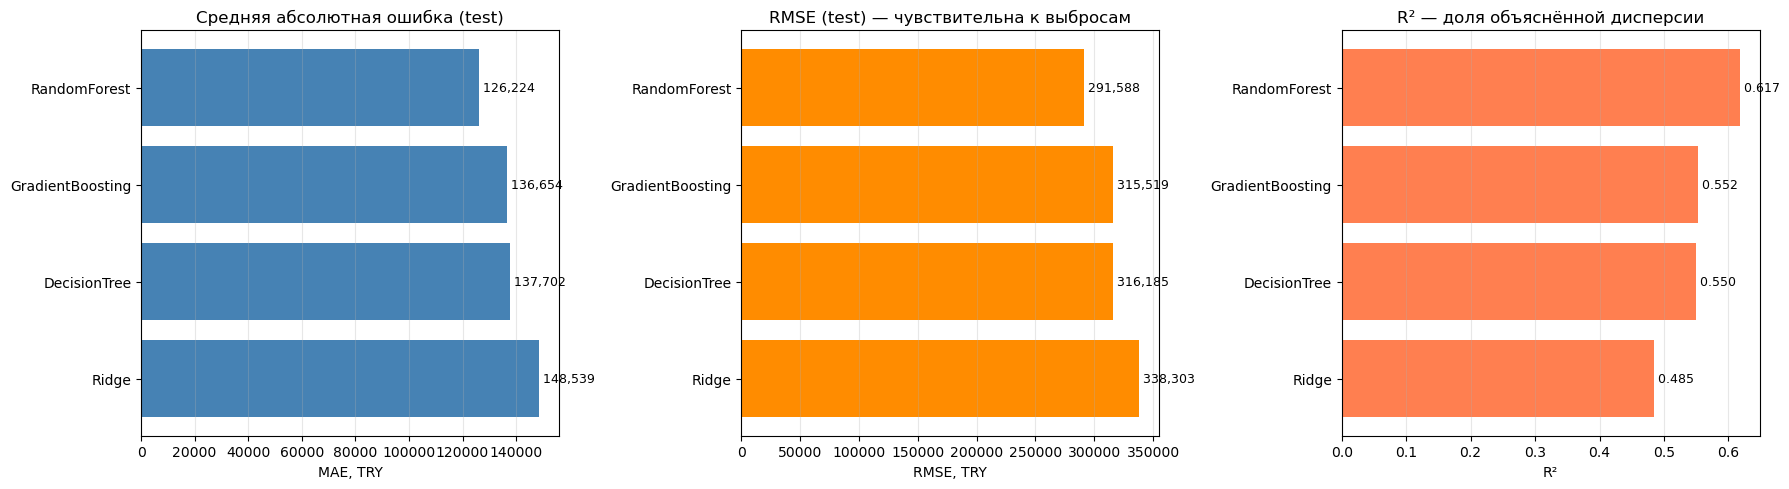

In [80]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- MAE ---
axes[0].barh(df_test['Model'], df_test['MAE'], color='steelblue')
axes[0].set_xlabel('MAE, TRY')
axes[0].set_title('Средняя абсолютная ошибка (test)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_test['MAE']):
    axes[0].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

# --- RMSE ---
axes[1].barh(df_test['Model'], df_test['RMSE'], color='darkorange')
axes[1].set_xlabel('RMSE, TRY')
axes[1].set_title('RMSE (test) — чувствительна к выбросам')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_test['RMSE']):
    axes[1].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

# --- R² ---
axes[2].barh(df_test['Model'], df_test['R²'], color='coral')
axes[2].set_xlabel('R²')
axes[2].set_title('R² — доля объяснённой дисперсии')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_test['R²']):
    axes[2].text(v, i, f' {v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

🥇 Лучшая модель: RandomForest


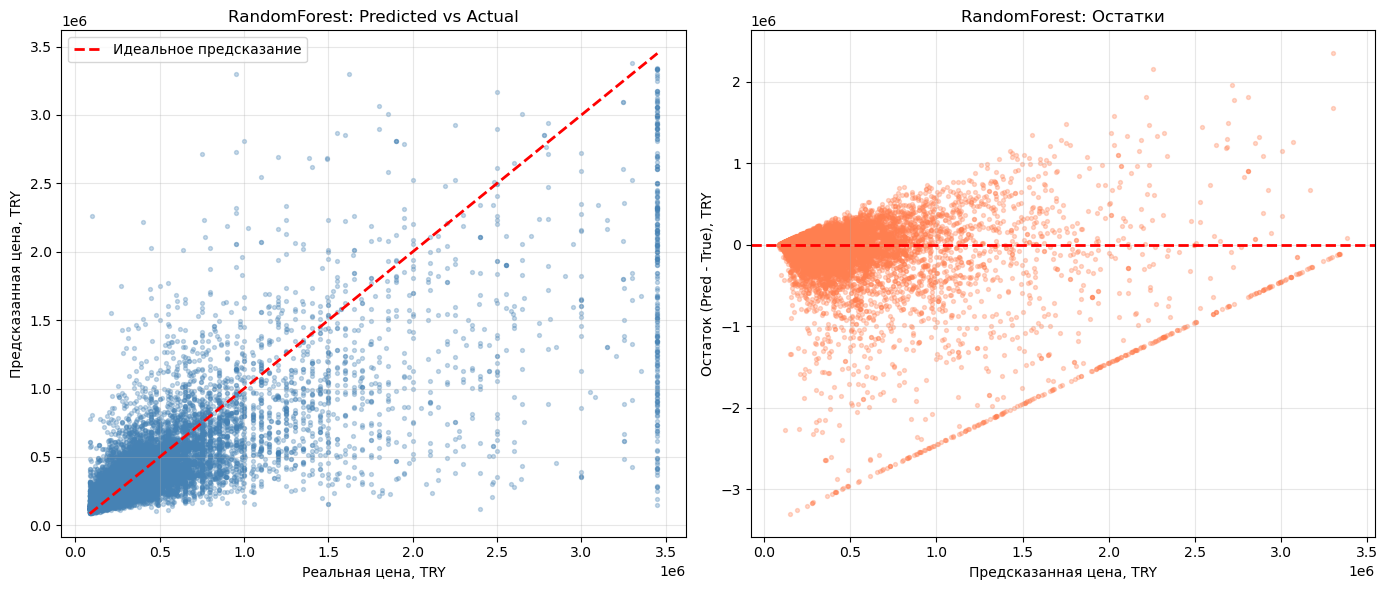

In [81]:
best_name = df_test.iloc[0]['Model']
print(f"🥇 Лучшая модель: {best_name}")

# Берём предсказания лучшей модели
best_pred_log = {
    'Ridge':            y_ridge_test,
    'DecisionTree':     y_dt_test,
    'RandomForest':     y_rf_test,
    'GradientBoosting': y_gbr_test,
}[best_name]

best_pred  = np.expm1(best_pred_log)
best_true  = np.expm1(y_test.values)

# --- Predicted vs Actual ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ограничим оси 1-99 перцентилями, чтобы выбросы не портили картину
q_low, q_high = np.percentile(best_true, [1, 99])
mask = (best_true >= q_low) & (best_true <= q_high)

axes[0].scatter(best_true[mask], best_pred[mask],
                alpha=0.3, s=8, color='steelblue')
axes[0].plot([q_low, q_high], [q_low, q_high],
             'r--', lw=2, label='Идеальное предсказание')
axes[0].set_xlabel('Реальная цена, TRY')
axes[0].set_ylabel('Предсказанная цена, TRY')
axes[0].set_title(f'{best_name}: Predicted vs Actual')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Residuals ---
residuals = best_pred - best_true
axes[1].scatter(best_pred[mask], residuals[mask],
                alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанная цена, TRY')
axes[1].set_ylabel('Остаток (Pred - True), TRY')
axes[1].set_title(f'{best_name}: Остатки')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### По графикам:

- Predicted vs Actual: точки в целом следуют красной пунктирной линии «идеального предсказания», но с заметным разбросом — модель улавливает общую зависимость, но допускает ошибки.
- Остатки: распределение несимметрично, есть систематический сдвиг (хвост вниз), остатки растут с ростом предсказаний — признак гетероскедастичности; модель сильнее занижает высокие цены.

Feature names: 129
Importances:  129


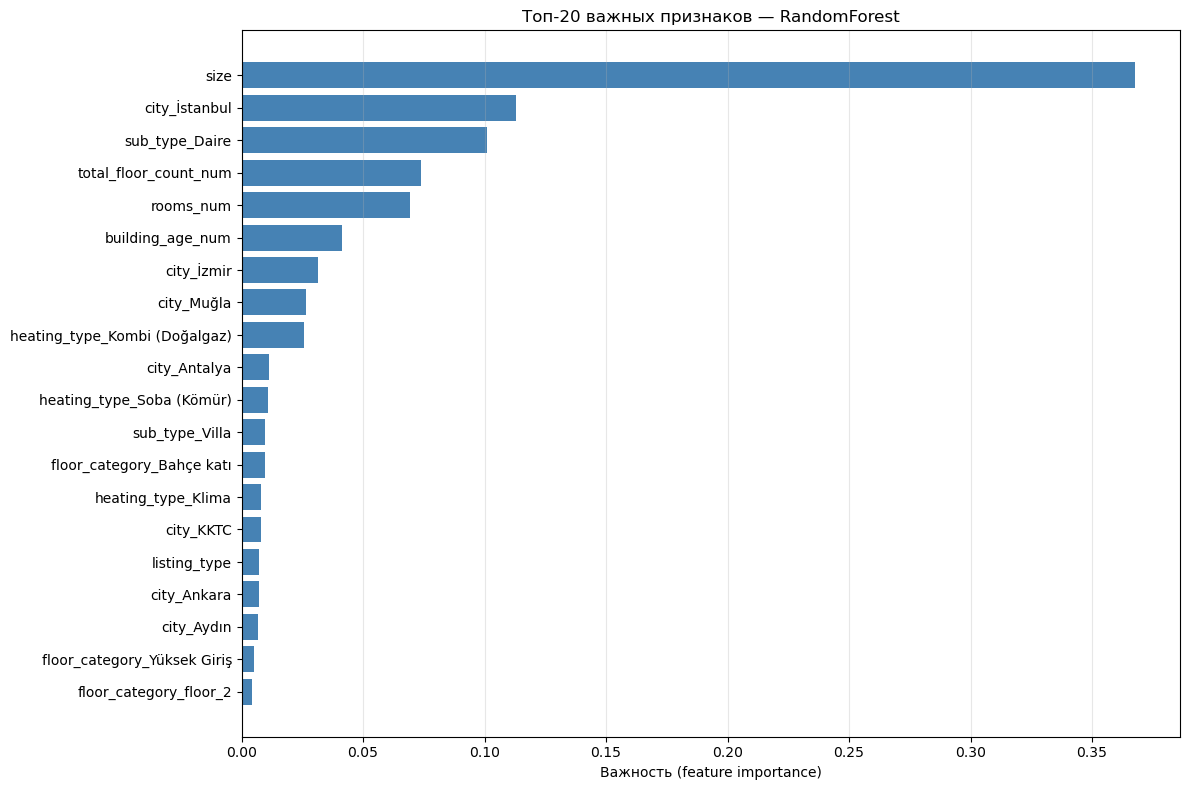

In [84]:
import matplotlib.pyplot as plt
import numpy as np

rf_model = best_models['RandomForest']
preprocessor = preprocessor_tree

try:
    feature_names = list(preprocessor.get_feature_names_out())
except AttributeError:
    # Fallback — генерируем имена по количеству
    feature_names = [f'f_{i}' for i in range(len(rf_model.feature_importances_))]

# Проверка длины — должно совпасть
print(f"Feature names: {len(feature_names)}")
print(f"Importances:  {len(rf_model.feature_importances_)}")
assert len(feature_names) == len(rf_model.feature_importances_), "Несовпадение!"

# Важности
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.barh([feature_names[i] for i in indices][::-1],
         [importances[i] for i in indices][::-1],
         color='steelblue')
plt.xlabel('Важность (feature importance)')
plt.title(f'Топ-20 важных признаков — RandomForest')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<strong>Вывод:</strong> Анализ важности признаков для лучшей модели (RandomForest) показал, какие факторы являются ключевыми для прогнозирования цены.

Топ-3 самых важных признака:
- size (площадь): Ожидаемо, самый главный фактор.
- city_İstanbul: Принадлежность к Стамбулу — второй по важности фактор, что подтверждает гипотезу о влиянии локации. Я знал, что они хотят продать свои квартиры в Стамбуле.
- sub_type_Daire (квартира): Тип объекта также играет важную роль.

<h3>3.5 Выбор финальной модели</h3>

In [ ]:
import joblib
import numpy as np

# Сохранение финальной модели + препроцессора в единый артефакт

# Выбираем лучшую модель из df_tuned (RandomForest)
best_name = df_tuned.iloc[0]['Model']
print(f"🥇 Финальная модель: {best_name}")

# Финальная модель + соответствующий препроцессор
best_model = best_models[best_name]
best_preprocessor = preprocessor_linear if best_name == 'Ridge' else preprocessor_tree

# Метрики лучшей модели
best_metrics = df_tuned[df_tuned['Model'] == best_name].iloc[0].to_dict()

# Формируем артефакт — ВСЁ в одном файле

artifact = {
    'model': best_model,
    'preprocessor': best_preprocessor,
    'metrics': best_metrics,
    'feature_cols': list(X_train.columns),          # порядок колонок
    'num_features': num_features,
    'cat_features': cat_features,
    'metadata': {
        'cities': sorted(X_train['city'].unique().tolist()),
        'sub_types': sorted(X_train['sub_type'].unique().tolist()),
        'heating_types': sorted(X_train['heating_type'].unique().tolist()),
        'floor_categories': sorted(X_train['floor_category'].unique().tolist()),
        'listing_types': sorted(X_train['listing_type'].unique().tolist()),
    },
    'best_model_name': best_name,
}

# Сохраняем ВСЁ вместе
joblib.dump(artifact, 'full_pipeline.joblib')

print(f"\n✅ Артефакт сохранён: full_pipeline.joblib")
print(f"   Модель: {best_name}")
print(f"   R²:     {best_metrics['R²']:.3f}")
print(f"   MAE:    {best_metrics['MAE']:,.0f} TRY")
print(f"   RMSE:   {best_metrics['RMSE']:,.0f} TRY")
print(f"   MAPE:   {best_metrics['MAPE']:.2f}%")
print(f"\n   Препроцессор: {type(best_preprocessor).__name__}")
print(f"   Всего признаков после OHE: {best_preprocessor.transform(X_test.head(1)).shape[1]}")

### Тестирование full_pipeline.joblib

In [88]:
def load_model():
    try:
        artifact = joblib.load('full_pipeline.joblib')
        model_name = artifact.get('best_model_name', 'Unknown')
        metrics = artifact.get('metrics', {})
        
        print(f"✅ Модель {model_name} загружена успешно")
        print(f"   R²:   {metrics.get('R²', 0):.3f}")
        print(f"   MAE:  {metrics.get('MAE', 0):,.0f} TRY")
        print(f"   MAPE: {metrics.get('MAPE', 0):.2f}%")
        
        return artifact
    except FileNotFoundError:
        print("❌ Файл модели не найден. Проверьте путь: full_pipeline.joblib")
        return None
    except Exception as e:
        print(f"❌ Ошибка при загрузке модели: {e}")
        return None

In [89]:
load_model()

✅ Модель RandomForest загружена успешно
   R²:   0.595
   MAE:  126,926 TRY
   MAPE: 28.05%


{'model': RandomForestRegressor(max_depth=25, min_samples_leaf=10, n_estimators=200,
                       n_jobs=-1, random_state=42),
 'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', RobustScaler())]),
                                  ['size', 'rooms_num', 'building_age_num',
                                   'total_floor_count_num', 'listing_type']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('encoder',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_outp

### Общий итог проекта:

В ходе проекта была построена и протестирована модель машинного обучения, способная прогнозировать стоимость недвижимости в Турции на основе ее характеристик. Финальная модель (RandomForest) показывает адекватное качество (R² = 0.6) и может быть использована для предварительной оценки объектов. Модель и все необходимые для ее работы компоненты сохранены в файл full_pipeline.joblib, что позволяет использовать ее в дальнейшем, например, для интеграции в веб-приложение, как того требует постановка задачи.